In [12]:
from pathlib import Path
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

#Load existing dataset from CSV if it exists, otherwise create it from intial data 
#Return both the full dataframe and numpy arrays (x inputs, y outputs) 
csv_path = Path("function_1_data.csv")

def load_or_create_dataset():
    if csv_path.exists():
        df = pd.read_csv(csv_path)
    else:
        X_init = np.load('../data/initial_data/function_1/initial_inputs.npy')
        y_init = np.load('../data/initial_data/function_1/initial_outputs.npy')

        df = pd.DataFrame(X_init, columns=['x1', 'x2'])
        df['y'] = y_init
        df.to_csv(csv_path, index=False)

    X = df[['x1', 'x2']].to_numpy()
    y = df['y'].to_numpy()

    return df, X, y

df, X, y = load_or_create_dataset()


#checking shape of data 
print('Inputs Shape:', X.shape)
print('Outputs Shape:', y.shape)

Inputs Shape: (23, 2)
Outputs Shape: (23,)


In [14]:
#Append newly observed datapoints to existing CSV to keep a single up to date dataset

#Create a function to do this
def append_bo_result(x_new, y_new):
    df = pd.read_csv(csv_path)
    new_row = pd.DataFrame([[x_new[0], x_new[1], y_new]], columns=df.columns)
    df = pd.concat([df, new_row], ignore_index=True)
    df.to_csv(csv_path, index=False)
    return df

#Adding new values to my CSV df
#x_new = [0.759673, 0.752886]
#y_new = 5.325625517230111e-24

#df = append_bo_result(x_new, y_new)

# Refresh X and y from the updated live dataframe
X = df[['x1', 'x2']].to_numpy()
y = df['y'].to_numpy()


df.tail()

,x1,x2,y
18,0.745356,0.808449,-5.164476e-34
19,0.808718,0.744274,-1.361457e-33
20,0.784242,0.667952,-1.349960e-20
21,0.334463,0.152813,9.091430e-57
22,0.759673,0.752886,5.325626e-24


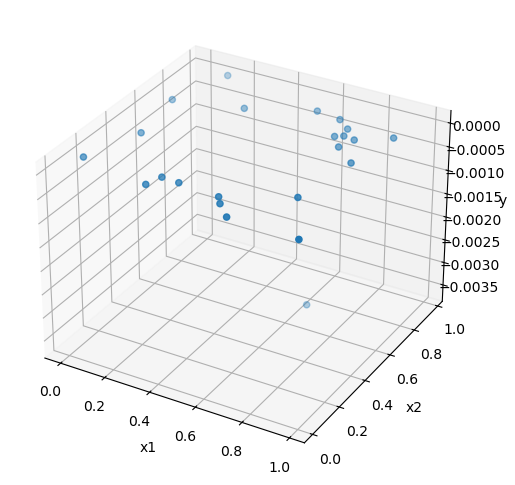

In [17]:
#3D scatter plot of obserevd function values

#create a figure
fig = plt.figure(figsize=(7,6))

#add a 3D axis to the figure
#111 means 1 row, 1 column, first plot position
ax = fig.add_subplot(111, projection = '3d')

#label the axis
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")

#plot the sampled points 
ax.scatter(df['x1'], df['x2'], df['y'])

plt.show()


In [19]:
#Define GP hyperparameters and make a grid / generate random candidate points for acqusition optimisation 
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF,ConstantKernel, WhiteKernel

#hyperparamters for GP surrogate model and acqusition function 
rbf_lengthscale = 0.1
noise_assumption = 1e-3
beta = 0.5

#Setting number of random candidate points
n_candidates = 5000

#Reproducible random number generator
rng = np.random.default_rng(42)

#Sample uniformly from [0, 1]^2
X_candidates = rng.random((n_candidates, 2))


#Previous grid set up 
#building a 2D grid to represent the test space 
#linspace(start, stop, num)
#g = np.linspace(0.0, 1.0, 101)   
#x1g, x2g = np.meshgrid(g, g)
#X_grid = np.column_stack([x1g.ravel(), x2g.ravel()])

In [21]:
#Fit gp to current data 

kernel = (ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.1,length_scale_bounds=(1e-3,5)) + WhiteKernel(noise_level=1e-3 , noise_level_bounds=(1e-6, 1)))
# To allow kernel to operate on the right scale for tiny numbers 
gp = GaussianProcessRegressor(kernel = kernel, normalize_y = True, random_state = 0)
gp.fit(X, y)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.001),
                         normalize_y=True, random_state=0)

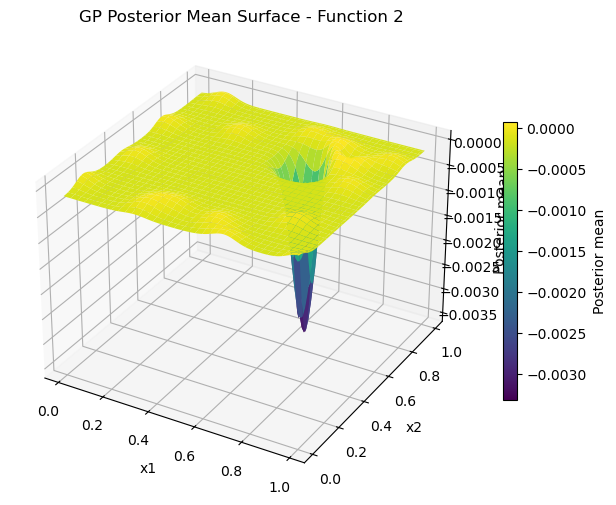

In [23]:
#Prosterior Mean Visualisation 

#create a grid to represent the mean surface 
g= np.linspace(0.01, 0.99, 101)
x1g, x2g = np.meshgrid(g, g)
# Flatten the two grid arrays into long 1D lists,
# then stack them together column by column
# so each row is one candidate point: [x1, x2]
X_grid = np.column_stack([x1g.ravel(), x2g.ravel()])

#now use the fitted GP to predict on X_grid.
#These are not the candidates I will use for optimisation! 
#Instead, it will just give a rough visualisation for the predicted mean at various intervals over this gird. 
#Optimisation points are predicted on a random n_candidates. 

mu = gp.predict(X_grid)

#reshape predictions back into grid form 
mu_grid = mu.reshape(x1g.shape)

# Create a new figure (canvas)
fig = plt.figure(figsize=(8, 6))

# Add a 3D axis to the figure
ax = fig.add_subplot(111, projection='3d')

# Plot the GP posterior mean as a smooth surface
# x1g = x-coordinates on the grid
# x2g = y-coordinates on the grid
# mu_grid = predicted height (posterior mean) at each grid point
surf = ax.plot_surface(x1g, x2g, mu_grid, cmap='viridis')

# Label the axes
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("Posterior mean")

# Add a title
ax.set_title("GP Posterior Mean Surface - Function 2")

# Add a colour bar so the colours are easier to interpret
fig.colorbar(surf, ax=ax, shrink=0.6, label="Posterior mean")

# Display the plot
plt.show()

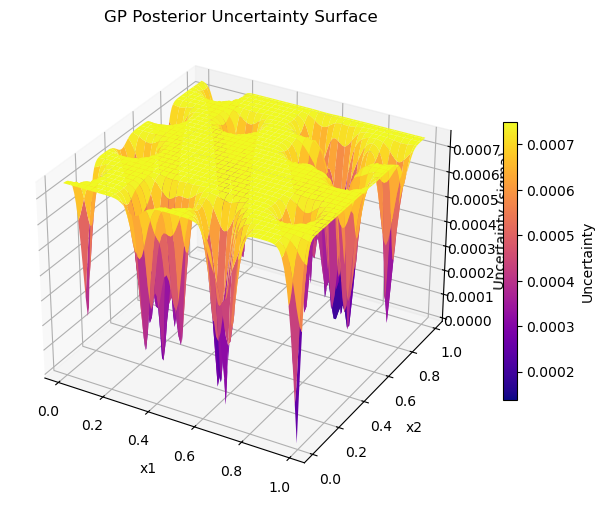

In [25]:
#Plot the uncertainty surface

# Ask the GP for the uncertainty (standard deviation)
mu, sigma = gp.predict(X_grid, return_std=True)

# Reshape the uncertainty so it matches the 2D grid
sigma_grid = sigma.reshape(x1g.shape)

# Create a new figure
fig = plt.figure(figsize=(8,6))

# Add a 3D axis
ax = fig.add_subplot(111, projection='3d')

# Plot the uncertainty surface
surf = ax.plot_surface(x1g, x2g, sigma_grid, cmap='plasma')

# Label the axes
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("Uncertainty (sigma)")

# Title
ax.set_title("GP Posterior Uncertainty Surface")

# Add a colour bar
fig.colorbar(surf, ax=ax, shrink=0.6, label="Uncertainty")

# Show the plot
plt.show()

In [34]:
#Setting up and running acqusition function

from scipy.stats import norm
import numpy as np

#UCB (Queries 1-13)

#posterior mean and std 
mu, std = gp.predict(X_candidates, return_std = True)
#std = np.maximum(std, 1e-12)

#UCB acquistion 
ucb= mu + beta * std

#choose next query point 
idx = np.argmax(ucb)
x_next = X_candidates[idx]

print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f})")


# Expected Improvement (considered in queries 12-13)

xi = 0.01

# Predict mean and standard deviation on candidate points
mu, std = gp.predict(X_candidates, return_std=True)

# Current best observed value
y_best = np.max(y)

#Expected Improvement
improvement = mu - y_best - xi
Z = improvement / std
ei = improvement * norm.cdf(Z) + std * norm.pdf(Z)

# Avoid division by zero
std = np.maximum(std, 1e-9)

# Choose the next query point as the candidate with the highest EI
idx = np.argmax(ei)
x_next = X_candidates[idx]

print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f})")

x_next = (0.868499, 0.734926)
x_next = (0.943021, 0.694925)


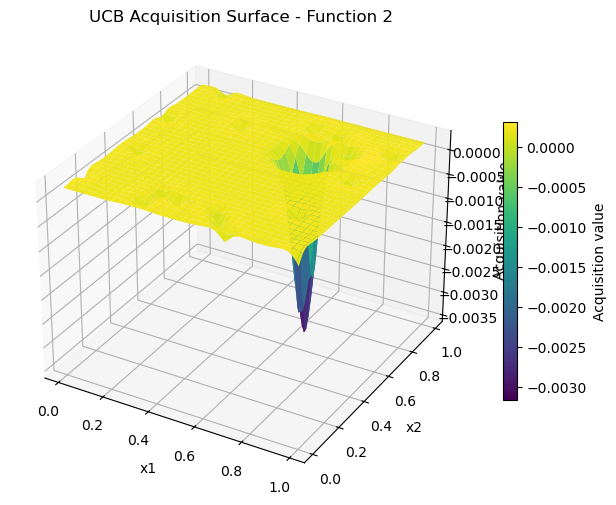

In [38]:
#Aqusition Function Visualisation 

#Creating a grid for visualisation
#Note that the acqusition function for optimisaitions has not used a grid as it is too restrictive
#Grid is used in this case to allow a general shape of the function to be visualised, even if coarse
g = np.linspace(0.01, 0.99, 101)
x1g, x2g = np.meshgrid(g, g)
X_grid = np.column_stack([x1g.ravel(), x2g.ravel()])

# Predict mean and standard deviation on the grid
mu, std = gp.predict(X_grid, return_std=True)

# Compute UCB acquisition on the grid
ucb = mu + beta * std

# Reshape back into grid form
ucb_grid = ucb.reshape(x1g.shape)

# Create a new figure
fig = plt.figure(figsize=(8, 6))

# Add a 3D axis
ax = fig.add_subplot(111, projection='3d')

# Plot the acquisition surface
surf = ax.plot_surface(x1g, x2g, ucb_grid, cmap='viridis')

# Label the axes
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("Acquisition value")

# Add a title
ax.set_title("UCB Acquisition Surface - Function 2")

# Add a colour bar
fig.colorbar(surf, ax=ax, shrink=0.6, label="Acquisition value")

# Display the plot
plt.show()


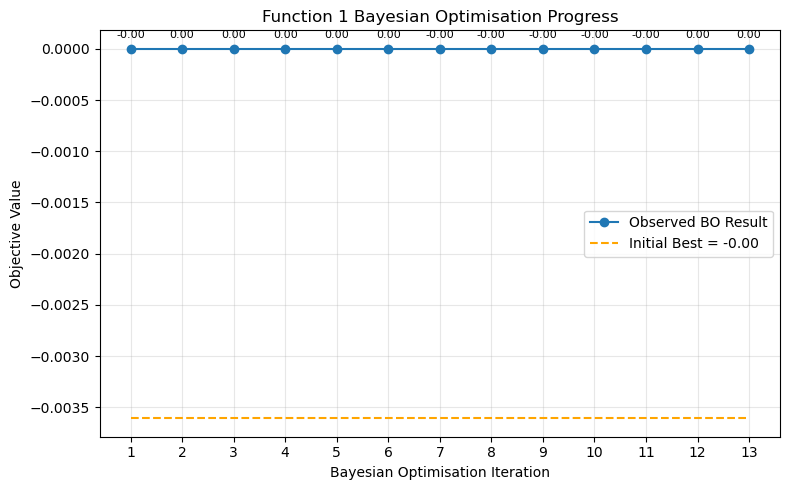

In [40]:
# Plot a graph to track function_1 Bayesian Optimisation progress 

#Intial y_best existing in origional dataset 
INITIAL_BEST_Y =  -0.003606063

# Load my live CSV data file 
df_plot = pd.read_csv(csv_path)
df_plot["y"] = pd.to_numeric(df_plot["y"], errors="coerce")

# Select Bayesian Optimisation data from existing dataset and assign them indexes for plotting
bo = df_plot.tail(13).copy()
bo["iteration"] = range(1, len(bo) + 1)

x = bo["iteration"]
y = bo["y"]

# Flat baseline using your manual value
baseline = np.full(len(y), INITIAL_BEST_Y)

# Plot the graph 
plt.figure(figsize=(8, 5))

plt.plot(x, y, marker="o", label="Observed BO Result")
plt.plot(x, baseline, linestyle="--", color="orange", label=f"Initial Best = {INITIAL_BEST_Y:.2f}")

# Labels on points
for i, val in zip(x, y):
    plt.annotate(f"{val:.2f}", (i, val), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.xlabel("Bayesian Optimisation Iteration")
plt.ylabel("Objective Value")
plt.title("Function 1 Bayesian Optimisation Progress")
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("function_1_bo_progress.png", dpi=300, bbox_inches="tight")
plt.show()